In [1]:
#1. Extract the data
import pandas as pd

df = pd.read_csv(r"C:\Users\jpmee\OneDrive\Desktop\insurance101.csv")
print(df.head())
print(df.shape)
print(df.columns)

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
(1338, 7)
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')


In [7]:
#2. Provide Raw Data
print(df.info())
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
Duplicates: 1


In [14]:
#3. Transform the data
df_clean = df.drop_duplicates().copy()

for col in ["sex", "smoker", "region"]:
    df_clean[col] = df_clean[col].astype(str).str.strip().str.lower()

print(df_clean.shape)
print(df_clean.isnull().sum())
print(df_clean.duplicated().sum())
df_clean.head(10)

(1337, 7)
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
0


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [15]:
#4. Load the data
# 4. Load / Save Cleaned Data
import os

os.makedirs("data/cleaned", exist_ok=True)

df_clean.to_csv("data/cleaned/insurance101_clean.csv", index=False)

print("Cleaned data loaded/saved successfully ✅")
print("Saved to: data/cleaned/insurance101_clean.csv")

Cleaned data loaded/saved successfully ✅
Saved to: data/cleaned/insurance101_clean.csv


In [21]:
#5. Summary Statistics
summary = df_clean.describe(include="all").transpose().round(2)
print(summary.to_string())

           count unique        top  freq          mean           std        min       25%        50%          75%          max
age       1337.0    NaN        NaN   NaN     39.222139     14.044333       18.0      27.0       39.0         51.0         64.0
sex         1337      2       male   675           NaN           NaN        NaN       NaN        NaN          NaN          NaN
bmi       1337.0    NaN        NaN   NaN     30.663452      6.100468      15.96     26.29       30.4         34.7        53.13
children  1337.0    NaN        NaN   NaN      1.095737      1.205571        0.0       0.0        1.0          2.0          5.0
smoker      1337      2         no  1063           NaN           NaN        NaN       NaN        NaN          NaN          NaN
region      1337      4  southeast   364           NaN           NaN        NaN       NaN        NaN          NaN          NaN
charges   1337.0    NaN        NaN   NaN  13279.121487  12110.359656  1121.8739  4746.344  9386.1613  16657.717

In [22]:
#6. Analyze the average charges by smoker and non-smoker
print(
    df_clean.groupby("smoker")["charges"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
    .to_string()
)

        count      mean    median       min       max
smoker                                               
no       1063   8440.66   7345.73   1121.87  36910.61
yes       274  32050.23  34456.35  12829.46  63770.43


In [24]:
#7. Analyze the Average charges by gender
print(
    df_clean.groupby("sex")["charges"]
    .agg(["count", "mean"])
    .round(2)
    .to_string()
)

        count      mean
sex                    
female    662  12569.58
male      675  13975.00


In [25]:
#8. Analyze the average charges by region
print(
    df_clean.groupby("region")["charges"]
    .agg(["count", "mean"])
    .round(2)
    .to_string()
)

           count      mean
region                    
northeast    324  13406.38
northwest    324  12450.84
southeast    364  14735.41
southwest    325  12346.94


In [26]:
#9. Analyze the average charges by the number of children
print(
    df_clean.groupby("children")["charges"]
    .agg(["count", "mean"])
    .round(2)
    .to_string()
)

          count      mean
children                 
0           573  12384.70
1           324  12731.17
2           240  15073.56
3           157  15355.32
4            25  13850.66
5            18   8786.04


In [27]:
#10. Correlation Analysis
print(df_clean[["age", "bmi", "children", "charges"]].corr().round(3).to_string())

            age    bmi  children  charges
age       1.000  0.109     0.042    0.298
bmi       0.109  1.000     0.013    0.198
children  0.042  0.013     1.000    0.067
charges   0.298  0.198     0.067    1.000


In [8]:
#11. Running tests for the true file path to analyze charges based on Body Mass Index or BMI
import os
import pandas as pd

home = os.path.expanduser("~")

possible_paths = [
    os.path.join(home, "Desktop", "insurance101.csv"),
    os.path.join(home, "OneDrive", "Desktop", "insurance101.csv"),
    os.path.join(home, "Downloads", "insurance101.csv"),
    os.path.join(home, "OneDrive", "Downloads", "insurance101.csv"),
]

for path in possible_paths:
    print(path, "->", os.path.exists(path))

C:\Users\jpmee\Desktop\insurance101.csv -> False
C:\Users\jpmee\OneDrive\Desktop\insurance101.csv -> True
C:\Users\jpmee\Downloads\insurance101.csv -> False
C:\Users\jpmee\OneDrive\Downloads\insurance101.csv -> False


In [10]:
#12. Analyze average BMI
import pandas as pd

file_path = r"C:\Users\jpmee\OneDrive\Desktop\insurance101.csv"   # replace with your true path

df = pd.read_csv(file_path)
df_clean = df.drop_duplicates().copy()

for col in ["sex", "smoker", "region"]:
    df_clean[col] = df_clean[col].str.strip().str.lower()

print("Clean shape:", df_clean.shape)
print(df_clean["bmi"].describe().round(2))

Clean shape: (1337, 7)
count    1337.00
mean       30.66
std         6.10
min        15.96
25%        26.29
50%        30.40
75%        34.70
max        53.13
Name: bmi, dtype: float64


In [12]:
#13. Analyze charges based on BMI
import os
import pandas as pd

home = os.path.expanduser("~")

possible_paths = [
    os.path.join(home, "Desktop", "insurance101.csv"),
    os.path.join(home, "OneDrive", "Desktop", "insurance101.csv"),
    os.path.join(home, "Downloads", "insurance101.csv"),
    os.path.join(home, "OneDrive", "Downloads", "insurance101.csv"),
]

file_path = next((p for p in possible_paths if os.path.exists(p)), None)

if not file_path:
    raise FileNotFoundError("insurance101.csv not found")

df = pd.read_csv(file_path)
df_clean = df.drop_duplicates().copy()

for col in ["sex", "smoker", "region"]:
    df_clean[col] = df_clean[col].str.strip().str.lower()

# BMI groups
df_clean["bmi_category"] = pd.cut(
    df_clean["bmi"],
    bins=[0, 18.5, 25, 30, 100],
    labels=["Underweight", "Normal", "Overweight", "Obese"]
)

# Average charges by BMI category
bmi_analysis = (
    df_clean.groupby("bmi_category", observed=False)["charges"]
    .agg(["count", "mean", "min", "max"])
    .round(2)
)

print("\nAverage Charges Based on BMI")
print(bmi_analysis.to_string())

print("\nBMI and Charges Correlation:")
print(round(df_clean["bmi"].corr(df_clean["charges"]), 3))


Average Charges Based on BMI
              count      mean      min       max
bmi_category                                    
Underweight      21   8657.62  1621.34  32734.19
Normal          226  10435.44  1121.87  35069.37
Overweight      386  10997.80  1252.41  38245.59
Obese           704  15580.70  1131.51  63770.43

BMI and Charges Correlation:
0.198


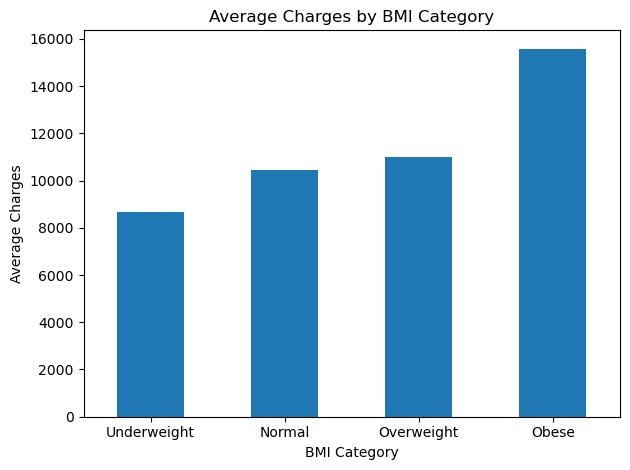

In [13]:
#14. Add bar chart to base average charges based on BMI on weight categories
import matplotlib.pyplot as plt

bmi_analysis["mean"].plot(kind="bar")
plt.title("Average Charges by BMI Category")
plt.xlabel("BMI Category")
plt.ylabel("Average Charges")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

smoker
no      8440.66
yes    32050.23
Name: charges, dtype: float64


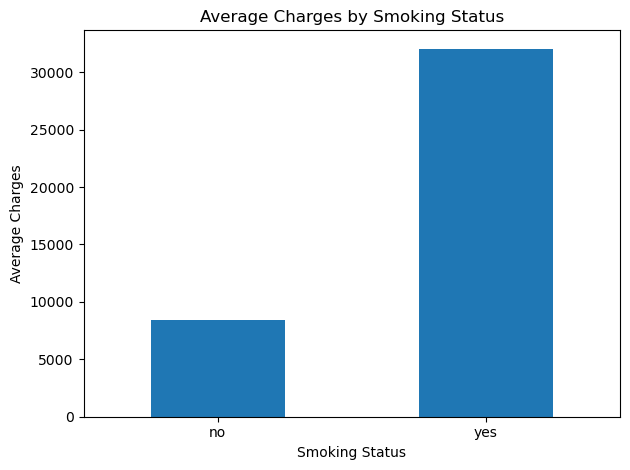

In [14]:
#15. Bar chart based on average charges based on smoking status
import os
import pandas as pd
import matplotlib.pyplot as plt

# Find the file
home = os.path.expanduser("~")
possible_paths = [
    os.path.join(home, "Desktop", "insurance101.csv"),
    os.path.join(home, "OneDrive", "Desktop", "insurance101.csv"),
    os.path.join(home, "Downloads", "insurance101.csv"),
    os.path.join(home, "OneDrive", "Downloads", "insurance101.csv"),
]

file_path = next((p for p in possible_paths if os.path.exists(p)), None)

if not file_path:
    raise FileNotFoundError("insurance101.csv not found")

# Load and clean
df = pd.read_csv(file_path)
df_clean = df.drop_duplicates().copy()

for col in ["sex", "smoker", "region"]:
    df_clean[col] = df_clean[col].str.strip().str.lower()

# Average charges by smoker
smoker_avg = (
    df_clean.groupby("smoker")["charges"]
    .mean()
    .round(2)
)

print(smoker_avg)

# Create chart
smoker_avg.plot(kind="bar")
plt.title("Average Charges by Smoking Status")
plt.xlabel("Smoking Status")
plt.ylabel("Average Charges")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

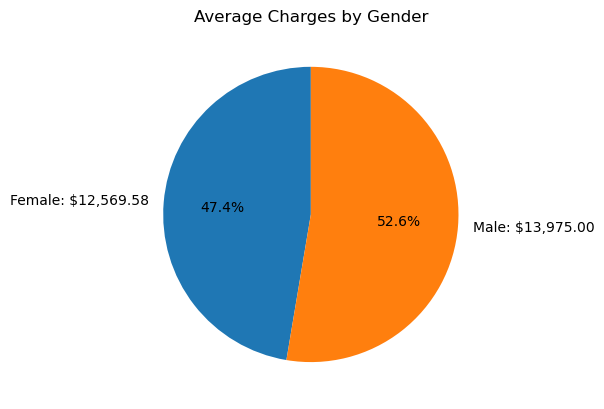

In [17]:
#16. Pie chart on average charges based on gender
import os
import pandas as pd
import matplotlib.pyplot as plt

home = os.path.expanduser("~")
possible_paths = [
    os.path.join(home, "Desktop", "insurance101.csv"),
    os.path.join(home, "OneDrive", "Desktop", "insurance101.csv"),
    os.path.join(home, "Downloads", "insurance101.csv"),
    os.path.join(home, "OneDrive", "Downloads", "insurance101.csv"),
]

file_path = next((p for p in possible_paths if os.path.exists(p)), None)

if not file_path:
    raise FileNotFoundError("insurance101.csv not found")

df = pd.read_csv(file_path)
df_clean = df.drop_duplicates().copy()

for col in ["sex", "smoker", "region"]:
    df_clean[col] = df_clean[col].str.strip().str.lower()

gender_avg = df_clean.groupby("sex")["charges"].mean().round(2)
gender_avg.index = gender_avg.index.str.title()

labels = [f"{gender}: ${value:,.2f}" for gender, value in gender_avg.items()]

plt.figure(figsize=(6, 6))
plt.pie(
    gender_avg,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Average Charges by Gender")
plt.tight_layout()
plt.show()

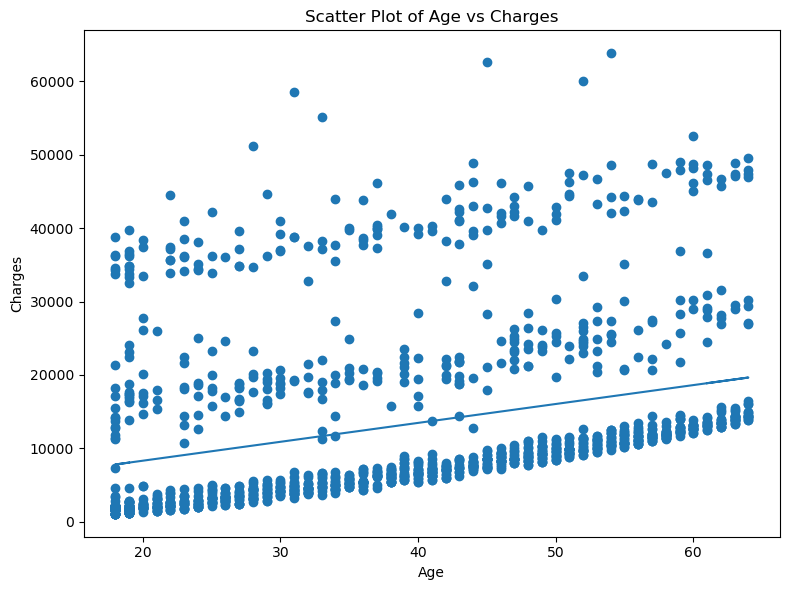

In [18]:
#17. Scatter chart on average charges based on ages
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Find the file
home = os.path.expanduser("~")
possible_paths = [
    os.path.join(home, "Desktop", "insurance101.csv"),
    os.path.join(home, "OneDrive", "Desktop", "insurance101.csv"),
    os.path.join(home, "Downloads", "insurance101.csv"),
    os.path.join(home, "OneDrive", "Downloads", "insurance101.csv"),
]

file_path = next((p for p in possible_paths if os.path.exists(p)), None)

if not file_path:
    raise FileNotFoundError("insurance101.csv not found")

df = pd.read_csv(file_path)
df_clean = df.drop_duplicates().copy()

for col in ["sex", "smoker", "region"]:
    df_clean[col] = df_clean[col].str.strip().str.lower()

x = df_clean["age"]
y = df_clean["charges"]

plt.figure(figsize=(8, 6))
plt.scatter(x, y)

# trend line
m, b = np.polyfit(x, y, 1)
plt.plot(x, m * x + b)

plt.title("Scatter Plot of Age vs Charges")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.tight_layout()
plt.show()

In [21]:
#18. Prediction model performance based on top coeffiecents. 
import os
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Find and load file
home = os.path.expanduser("~")
possible_paths = [
    os.path.join(home, "Desktop", "insurance101.csv"),
    os.path.join(home, "OneDrive", "Desktop", "insurance101.csv"),
    os.path.join(home, "Downloads", "insurance101.csv"),
    os.path.join(home, "OneDrive", "Downloads", "insurance101.csv"),
]

file_path = next((p for p in possible_paths if os.path.exists(p)), None)
if not file_path:
    raise FileNotFoundError("insurance101.csv not found")

df = pd.read_csv(file_path)

# 2. Clean data
df = df.drop_duplicates().copy()

for col in ["sex", "smoker", "region"]:
    df[col] = df[col].str.strip().str.lower()

# 3. Convert text columns to numbers
df_model = pd.get_dummies(df, columns=["sex", "smoker", "region"], drop_first=True)

# 4. Define X and y
X = df_model.drop("charges", axis=1)
y = df_model["charges"]

# 5. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 6. Train model
model = LinearRegression()
model.fit(X_train, y_train)

# 7. Predict
y_pred = model.predict(X_test)

# 8. Evaluate
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Performance")
print(f"MAE: {mae:,.2f}")
print(f"MSE: {mse:,.2f}")
print(f"R²: {r2:.3f}")
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values("Coefficient", ascending=False)

print("\nTop coefficients:")
print(coefficients.head(10).to_string(index=False))

Model Performance
MAE: 4,177.05
MSE: 35,478,020.68
R²: 0.807

Top coefficients:
         Feature  Coefficient
      smoker_yes 23077.764593
        children   533.009989
             bmi   318.701441
             age   248.210720
        sex_male  -101.542054
region_northwest  -391.761455
region_southwest  -659.139752
region_southeast  -838.919616


In [10]:
import pandas as pd
import os

df = pd.read_csv("insurance.csv")

print("Shape:", df.shape)
print(df.head())

Shape: (1338, 7)
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [13]:
df = pd.read_csv("insurance.csv")